In [2]:
#Cell 1 — load everything:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import joblib

from src.utils import load_config, set_seed
from src.models.baseline import train_logistic_regression, train_decision_tree
from src.evaluation.metrics import evaluate_model, print_metrics, results_to_dataframe

cfg = load_config()
set_seed(cfg["project"]["random_state"])
processed_dir = cfg["paths"]["processed_dir"]

# Raw (unscaled) - for Decision Tree
X_train_raw = pd.read_parquet(os.path.join(processed_dir, "X_train_raw.parquet"))
X_test_raw = pd.read_parquet(os.path.join(processed_dir, "X_test_raw.parquet"))

# Scaled - for Logistic Regression
X_train_scaled = pd.read_parquet(os.path.join(processed_dir, "X_train_scaled.parquet"))
X_test_scaled = pd.read_parquet(os.path.join(processed_dir, "X_test_scaled.parquet"))

# Labels
y_train = pd.read_parquet(os.path.join(processed_dir, "y_train.parquet"))["label_binary"]
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet"))["label_binary"]

print("Shapes loaded OK:")
print("  X_train_raw   :", X_train_raw.shape)
print("  X_test_raw    :", X_test_raw.shape)
print("  X_train_scaled:", X_train_scaled.shape)
print("  X_test_scaled :", X_test_scaled.shape)
print("  y_train       :", y_train.shape)
print("  y_test        :", y_test.shape)

Shapes loaded OK:
  X_train_raw   : (178464, 67)
  X_test_raw    : (44616, 67)
  X_train_scaled: (178464, 67)
  X_test_scaled : (44616, 67)
  y_train       : (178464,)
  y_test        : (44616,)


In [3]:
#Cell 2 — train + evaluate Logistic Regression:
seed = cfg["project"]["random_state"]

lr_model, lr_train_time = train_logistic_regression(X_train_scaled, y_train, random_state=seed)

lr_metrics = evaluate_model(lr_model, X_test_scaled, y_test, model_name="Logistic Regression")
lr_metrics["train_time_sec"] = round(lr_train_time, 4)

print_metrics(lr_metrics)

d:\MSc_Project\Network_IDS_Framework\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


RESULTS: Logistic Regression
Accuracy   : 0.9988
Precision  : 0.9989
Recall     : 0.9990
F1-score   : 0.9989
ROC-AUC    : 0.9999
PR-AUC     : 0.9998
FPR        : 0.0015
FNR        : 0.0010
------------------------------------------------------------
Confusion Matrix:
              Predicted BENIGN   Predicted DDoS
Actual BENIGN        18,984                29
Actual DDoS              25            25,578
------------------------------------------------------------
Training time    : 4.9296 sec
Prediction time  : 0.0294 sec


In [4]:
#Cell 3 — train + evaluate Decision Tree:
dt_model, dt_train_time = train_decision_tree(X_train_raw, y_train, random_state=seed, max_depth=10)

dt_metrics = evaluate_model(dt_model, X_test_raw, y_test, model_name="Decision Tree")
dt_metrics["train_time_sec"] = round(dt_train_time, 4)

print_metrics(dt_metrics)

RESULTS: Decision Tree
Accuracy   : 0.9996
Precision  : 0.9998
Recall     : 0.9995
F1-score   : 0.9996
ROC-AUC    : 0.9998
PR-AUC     : 0.9998
FPR        : 0.0003
FNR        : 0.0005
------------------------------------------------------------
Confusion Matrix:
              Predicted BENIGN   Predicted DDoS
Actual BENIGN        19,008                 5
Actual DDoS              14            25,589
------------------------------------------------------------
Training time    : 2.4128 sec
Prediction time  : 0.0483 sec


In [5]:
#Cell 4 — comparison table + save:
results_df = results_to_dataframe([lr_metrics, dt_metrics])
print(results_df)

metrics_dir = cfg["paths"]["metrics_dir"]
models_dir = cfg["paths"]["models_dir"]

results_df.to_csv(os.path.join(metrics_dir, "baseline_results.csv"), index=False)

joblib.dump(lr_model, os.path.join(models_dir, "logistic_regression_baseline.joblib"))
joblib.dump(dt_model, os.path.join(models_dir, "decision_tree_baseline.joblib"))

print("\nSaved results table and both models.")

                 model  accuracy  precision    recall        f1   roc_auc  \
0        Decision Tree  0.999574   0.999805  0.999453  0.999629  0.999844   
1  Logistic Regression  0.998790   0.998867  0.999024  0.998946  0.999888   

     pr_auc       fpr       fnr  train_time_sec  prediction_time_sec     tn  \
0  0.999782  0.000263  0.000547          2.4128               0.0483  19008   
1  0.999803  0.001525  0.000976          4.9296               0.0294  18984   

   fp  fn     tp  
0   5  14  25589  
1  29  25  25578  

Saved results table and both models.


In [6]:
#Let's look at Decision Tree feature importances. This takes 2 minutes and is essential research #due-diligence.
#Add Cell 5 to 04_baseline_models.ipynb:

import pandas as pd

importances = pd.Series(dt_model.feature_importances_, index=X_train_raw.columns)
importances = importances.sort_values(ascending=False)

print("Top 15 most important features (Decision Tree):")
print(importances.head(15))

print(f"\nTop 1 feature ('{importances.index[0]}') accounts for "
      f"{importances.iloc[0]*100:.2f}% of total importance.")
print(f"Top 3 features together account for "
      f"{importances.iloc[:3].sum()*100:.2f}% of total importance.")

Top 15 most important features (Decision Tree):
Fwd Packet Length Max          0.541203
Total Length of Fwd Packets    0.453191
Init_Win_bytes_forward         0.002590
Destination Port               0.001243
Bwd Packet Length Min          0.000679
Bwd IAT Mean                   0.000421
Bwd Header Length              0.000251
Flow IAT Min                   0.000108
Bwd Packets/s                  0.000088
Flow Packets/s                 0.000075
Init_Win_bytes_backward        0.000067
Fwd IAT Min                    0.000050
FIN Flag Count                 0.000017
Flow Duration                  0.000013
Fwd IAT Std                    0.000005
dtype: float64

Top 1 feature ('Fwd Packet Length Max') accounts for 54.12% of total importance.
Top 3 features together account for 99.70% of total importance.


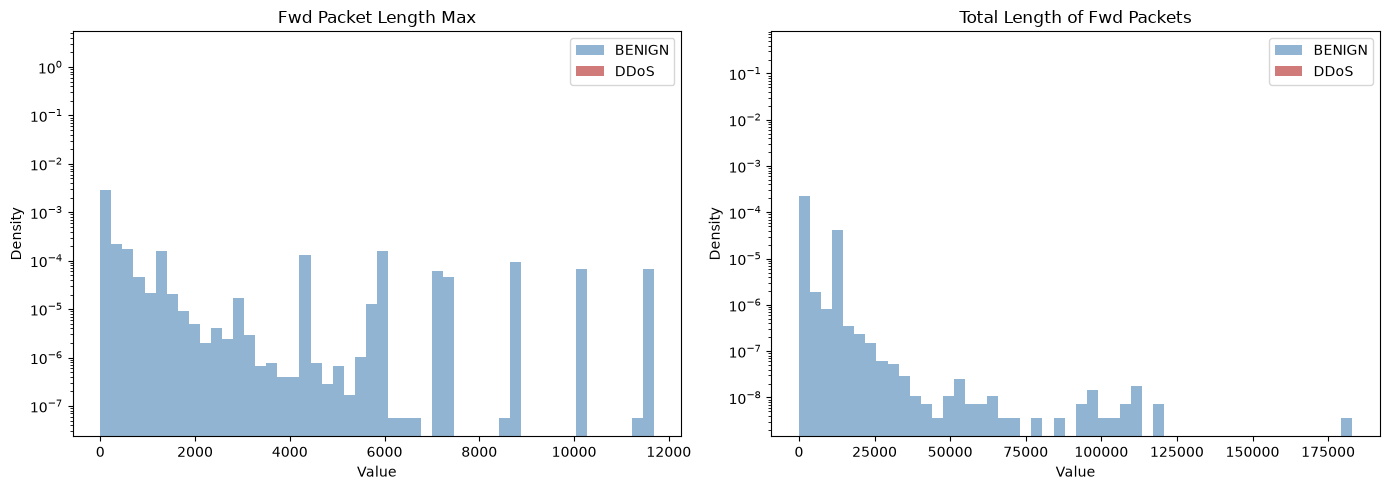

Descriptive stats by class:

--- Fwd Packet Length Max ---
                     mean          std  min   50%      max
label_binary                                              
0             1259.101140  2714.276404  0.0  42.0  11680.0
1               14.897111     6.738057  6.0  20.0     20.0

--- Total Length of Fwd Packets ---
                     mean          std  min   50%       max
label_binary                                               
0             2184.626116  4738.659837  0.0  70.0  183012.0
1               31.930593    11.969454  6.0  26.0      74.0



In [7]:
#Required check: look at the actual distributions
#Add this cell to 04_baseline_models.ipynb:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_features = ["Fwd Packet Length Max", "Total Length of Fwd Packets"]

for ax, feat in zip(axes, top_features):
    benign_vals = X_train_raw.loc[y_train == 0, feat]
    ddos_vals = X_train_raw.loc[y_train == 1, feat]

    ax.hist(benign_vals, bins=50, alpha=0.6, label="BENIGN", color="steelblue", density=True)
    ax.hist(ddos_vals, bins=50, alpha=0.6, label="DDoS", color="firebrick", density=True)
    ax.set_title(feat)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_yscale("log")  # log scale since these are likely highly skewed

plt.tight_layout()
plt.show()

print("Descriptive stats by class:\n")
for feat in top_features:
    print(f"--- {feat} ---")
    print(X_train_raw.groupby(y_train)[feat].describe()[["mean", "std", "min", "50%", "max"]])
    print()